Imports and config

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import *

from darts import TimeSeries
from darts.dataprocessing.transformers import WindowTransformer, StaticCovariatesTransformer

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)


In [ ]:
import os
# -------------------- CONFIG --------------------
DATA_FOLDER       = "./data"
FIXED_DATA_PATH   = construct_path(DATA_FOLDER, "fixed")
DATASET_PATH      = construct_path(DATA_FOLDER, "dataset")

TARGET_RAW        = "act_drone_strike_on_ua"          # count target
TARGET            = "act_drone_strike_on_ua_binary"   # binary target

# Forecasting setup
OUTPUT_CHUNK_LEN  = 7      # how many days ahead each model predicts in one shot
INPUT_LAGS        = 7      # how many past days of the target the model sees
MULTI_MODELS      = True   # direct strategy: one sub-model per horizon step

# CV / split
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.10, 0.20   # enforced by split_series_list
CV_STRIDE                       = 1                   # predict every day; retrain every OUTPUT_CHUNK_LEN days

# Which classifiers to benchmark in this run
CLASSIFIERS_TO_RUN = ["spe_dt", "spe_lgbm","naive", "logistic", "lightgbm", "xgboost", "catboost", ]

available_threads = get_available_threads()
print(f'CPU count: {available_threads}')

RANDOM_STATE      = 42
np.random.seed(RANDOM_STATE)


In [ ]:
regions,master_timeseries,regions_activity = load_data(data_path=FIXED_DATA_PATH,dataset_path=DATASET_PATH)


master_timeseries shape: (847, 1622)
regions: 25  -  ['cherkasy', 'chernihiv', 'chernivtsi', 'dnipropetrovsk', 'donetsk'] ...
start: 2022-09-28 00:00:00 end: 2025-01-21 00:00:00


In [ ]:
for_global_reset, global_weather_columns = get_engineered_features(
    master_timeseries=master_timeseries,
    data_path=FIXED_DATA_PATH,
    target_col=TARGET, 
    regions=regions,
    regions_activity=regions_activity,
    binarize_target=True,
    target_raw_col=TARGET_RAW
)

Shape after feature engineering: (16940, 113)
Target positive rate: 0.144


In [ ]:
# Future vs past covariate split
holiday_cols, future_covariates, exclude_cols, past_covariates = split_future_and_past_cov(for_global_reset,global_weather_columns,TARGET)

# future covariates : 27
# past covariates   : 83


## Build Darts TimeSeries and apply windowed transforms
Getting lag
 variabels

In [ ]:
# for_global_reset = for_global.reset_index()
target_series_list, past_covs_list,future_covs_list = build_ts_and_apply_window_transformer(for_global_reset,TARGET,past_covariates,future_covariates,ed_alpha=halflife_to_alpha(7))


Past-cov components: raw=83  transformed=415


## Encode static covariates and split 70/10/20


In [28]:
region_names, train_target, val_target, test_target, full_past_covs, full_fut_covs, target_for_cv, TRAIN_VAL_END,CV_START_VAL =\
      get_covs_and_encodings(target_series_list,past_covs_list,future_covs_list,TRAIN_FRAC,VAL_FRAC)

# regions: 20
train len (region 0): 593 days
val   len (region 0): 85 days
test  len (region 0): 169 days  <- untouched until the final evaluation
CV view length       : 676 days (train+val)
CV start on that view: 0.875  -> rolls across the val segment only


## Classifier setup

Each branch returns a Darts forecasting classifier. The `lags_*`,
`output_chunk_length`, and encoder setup are identical across models so the
comparison is fair; only the underlying estimator hyperparameters differ.

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin as _ClassifierMixin

class _FallbackLogisticRegression(_ClassifierMixin, BaseEstimator):
    """LogisticRegression that degrades to a constant-0 predictor when the
    training fold has only one class (avoids ValueError in sparse-region folds)."""
    def __init__(self, C=1.0, penalty="l2", class_weight=None,
                 solver="lbfgs", max_iter=2000, random_state=None):
        self.C = C
        self.penalty = penalty
        self.class_weight = class_weight
        self.solver = solver
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y):
        from sklearn.linear_model import LogisticRegression
        classes = np.unique(y)
        if len(classes) < 2:
            self._constant = classes[0]
            self.classes_ = np.array([0.0, 1.0])
        else:
            self._constant = None
            self._lr = LogisticRegression(
                C=self.C, penalty=self.penalty, class_weight=self.class_weight,
                solver=self.solver, max_iter=self.max_iter, random_state=self.random_state,
            )
            self._lr.fit(X, y)
            self.classes_ = self._lr.classes_
        return self

    def predict(self, X):
        if self._constant is not None:
            return np.full(len(X), self._constant)
        return self._lr.predict(X)

    def predict_proba(self, X):
        if self._constant is not None:
            probs = np.zeros((len(X), 2))
            probs[:, int(self._constant)] = 1.0
            return probs
        return self._lr.predict_proba(X)


# Shared kwargs that define the forecasting structure (NOT the estimator)
COMMON_KWARGS = get_common_kwargs()


def build_classifier(name: str):
    """Return a Darts forecasting classifier ready to .fit().

    name in {'lightgbm', 'xgboost', 'catboost', 'logistic', 'naive'}.
    """
    name = name.lower()
    from darts.models import SKLearnClassifierModel
    if name == "lightgbm":
        from darts.models import LightGBMClassifierModel
        return LightGBMClassifierModel(
            **COMMON_KWARGS,
            objective         = "binary",
            is_unbalance      = True,
            num_leaves        = 31,
            max_depth         = 5,
            min_child_samples = 30,
            subsample         = 0.8,
            colsample_bytree  = 0.8,
            learning_rate     = 0.05,
            n_estimators      = 500,
            random_state      = RANDOM_STATE,
            verbose           = -1,
        )

    if name == "xgboost":
        from darts.models import XGBClassifierModel
        
        # scale_pos_weight handles imbalance in xgboost
        pos_rate = float(for_global[TARGET].mean())
        spw      = (1.0 - pos_rate) / max(pos_rate, 1e-6)
        return XGBClassifierModel(
            **COMMON_KWARGS,
            objective         = "binary:logistic",
            eval_metric       = "logloss",
            scale_pos_weight  = spw,
            max_depth         = 5,
            min_child_weight  = 3,
            subsample         = 0.8,
            colsample_bytree  = 0.8,
            learning_rate     = 0.05,
            n_estimators      = 500,
            tree_method       = "hist",
            random_state      = RANDOM_STATE,
            verbosity         = 0,
        )

    if name == "catboost":
        from darts.models import CatBoostClassifierModel
        return CatBoostClassifierModel(
            **COMMON_KWARGS,
            loss_function     = "Logloss",
            auto_class_weights= "Balanced",  # catboost's imbalance handling
            depth             = 5,
            learning_rate     = 0.05,
            iterations        = 500,
            l2_leaf_reg       = 3,
            random_seed       = RANDOM_STATE,
            verbose           = False,
        )

    if name == "logistic":
        from sklearn.impute import SimpleImputer
        from sklearn.pipeline import make_pipeline
        from sklearn.preprocessing import StandardScaler

        base = make_pipeline(
            SimpleImputer(strategy="median"),
            StandardScaler(with_mean=True, with_std=True),
            _FallbackLogisticRegression(
                C=1.0, penalty="l2", class_weight="balanced",
                solver="lbfgs", max_iter=2000, random_state=RANDOM_STATE,
            ),
        )
        return SKLearnClassifierModel(model=base, **COMMON_KWARGS)

    if name == "spe_dt":
        from imbens.ensemble import SelfPacedEnsembleClassifier
        from sklearn.tree import DecisionTreeClassifier
        clf = SelfPacedEnsembleClassifier(
            estimator    = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
            n_estimators = 100,                
            random_state = RANDOM_STATE,
            n_jobs       = available_threads,
        )
        return SKLearnClassifierModel(model=clf, **COMMON_KWARGS)

    if name == "spe_lgbm":
        from lightgbm import LGBMClassifier
        from imbens.ensemble import SelfPacedEnsembleClassifier
        clf = SelfPacedEnsembleClassifier(
            estimator    = LGBMClassifier(           
                n_estimators=200,
                random_state=RANDOM_STATE,
                n_jobs=available_threads,                            
            ),
            n_estimators = 100,                       
            random_state = RANDOM_STATE,
            n_jobs       = 1,
        )
        return SKLearnClassifierModel(model=clf, **COMMON_KWARGS)



    if name == "naive":
        # Handled separately (no covariates, persistence only)
        return None

    raise ValueError(f"Unknown classifier name: {name!r}")


# Build simple LGBM For feature selection

In [30]:

model_feature_selection = build_classifier('lightgbm')
model_feature_selection.fit(
    series          = train_target,
    past_covariates = full_past_covs,
    future_covariates = full_fut_covs,
)


LightGBMClassifierModel(lags=7, lags_past_covariates=[-1], lags_future_covariates=(2, 7), output_chunk_length=7, output_chunk_shift=0, add_encoders={'cyclic': {'future': ['month', 'week', 'dayofyear', 'dayofweek', 'day']}}, likelihood=classprobability, random_state=42, multi_models=True, use_static_covariates=True, categorical_past_covariates=None, categorical_future_covariates=None, categorical_static_covariates=None, objective=binary, is_unbalance=True, num_leaves=31, max_depth=5, min_child_samples=30, subsample=0.8, colsample_bytree=0.8, learning_rate=0.05, n_estimators=500, verbose=-1)

In [31]:
gain_imps = {"Feature": model_feature_selection.lagged_feature_names}
split_imps = {"Feature": model_feature_selection.lagged_feature_names}
estimators = model_feature_selection.model.estimators_
for h, est in enumerate(estimators, start=1):
    gain_imps[f"h{h}_gain"] = est.booster_.feature_importance(importance_type='gain')
    split_imps[f"h{h}_split"] = est.booster_.feature_importance(importance_type='split')

# 3. Convert to DataFrames
df_gain = pd.DataFrame(gain_imps)
df_split = pd.DataFrame(split_imps)

# mean score across all horizons 
# to sort the entire DataFrame logically, rather than just sorting by h1.
df_gain["agg_gain"] = df_gain.iloc[:, 1:].mean(axis=1)
df_gain["total_gain"] = df_gain.iloc[:, 1:].sum(axis=1)
df_split["agg_split"] = df_split.iloc[:, 1:].mean(axis=1)


df_gain = df_gain.sort_values(by="agg_gain", ascending=False).reset_index(drop=True)
df_split = df_split.sort_values(by="agg_split", ascending=False).reset_index(drop=True)


df_gain.to_csv('prelimFeatureImportanceClassifier.csv')
threshold = .99
print(df_gain.head(20))

,Feature,h1_gain,h2_gain,h3_gain,h4_gain,h5_gain,h6_gain,h7_gain,agg_gain,total_gain
0,Activity_Level_statcov_target_act_drone_strike...,50269.807481,50935.449666,50887.804222,50178.059097,50142.282699,49624.939634,50547.233980,50369.368111,402954.944891
1,rolling_rsum14_14_act_total_daily_strike_event...,6952.754382,5155.166449,5188.422071,5220.623059,5186.980416,1047.495941,4741.179801,4784.660303,38277.282421
2,rolling_rsum14_14_fin_usd_rub_rate_pastcov_lag-1,1290.501968,5005.691898,524.342947,3509.812219,3726.085846,2316.234836,2495.317587,2695.426757,21563.414058
3,ewm_ewma14_act_drone_infra_ua_residential_inte...,2219.583197,1778.378177,2402.899508,2120.649747,2189.578154,2421.003680,3065.793828,2313.983756,18511.870047
4,ewm_ewma14_acled_other_ua_disrupted_weapons_us...,1891.736686,2823.876261,2430.138324,2200.118800,2049.055182,2020.260217,2562.852273,2282.576820,18260.614564
5,region_statcov_target_act_drone_strike_on_ua_b...,2268.439922,2511.476953,2291.107044,2130.988618,1927.097348,1811.405539,1618.176103,2079.813075,16638.504602
6,ewm_ewma14_act_total_daily_strike_events_pastc...,397.477339,197.492119,762.693310,1143.153329,280.377768,7367.634344,4056.832656,2029.380124,16235.040989
7,ewm_ewma14_act_drone_infra_ua_health_intent_pa...,2135.042126,1954.213467,1921.634049,1787.591660,1899.902178,1612.430328,1233.065782,1791.982799,14335.862390
8,ewm_ewma14_acled_other_rus_armed_clash_pastcov...,1668.399246,1025.063509,886.355418,1394.843036,2252.173022,1910.086455,1663.394010,1542.902099,12343.216795
9,ewm_ewma14_acled_other_rus_shelling_artillery_...,1599.179301,1600.441253,1409.078800,1355.862552,1168.448491,1007.926200,986.697176,1303.947682,10431.581453


In [32]:
top_100_features = df_gain.head(100)['Feature'].to_list()
top_100_features_dict = clean_feature_names(top_100_features)

In [33]:
past_covs_list   = [subset_safe(ts, top_100_features_dict['pastcov_features_base']) for ts in past_covs_list]
future_covs_list = [subset_safe(ts, top_100_features_dict['futcov_features_base'])  for ts in future_covs_list]

region_names, train_target, val_target, test_target, full_past_covs, full_fut_covs, target_for_cv,TRAIN_VAL_END,CV_START_VAL = \
    get_covs_and_encodings(target_series_list,past_covs_list,future_covs_list,TRAIN_FRAC,VAL_FRAC)

# regions: 20
train len (region 0): 593 days
val   len (region 0): 85 days
test  len (region 0): 169 days  <- untouched until the final evaluation
CV view length       : 676 days (train+val)
CV start on that view: 0.875  -> rolls across the val segment only


In [34]:
sample = past_covs_list[0]
base_set = top_100_features_dict['pastcov_features_base']
present  = base_set & set(sample.components)
missing  = base_set - set(sample.components)
print(f"{len(present)}/{len(base_set)} base features present in past_covs")
if missing:
    print("missing (first 10):", list(missing)[:10])
sample = future_covs_list[0]
base_set = top_100_features_dict['futcov_features_base']
present  = base_set & set(sample.components)
missing  = base_set - set(sample.components)
print(f"{len(present)}/{len(base_set)} base features present in future_covs")
if missing:
    print("missing (first 10):", list(missing)[:10])

36/36 base features present in past_covs
10/10 base features present in future_covs


##  Evaluation utilities

Three complementary views of quality, all from one pass over the predictions:

| scope              | granularity                           |
| ------------------ | ------------------------------------- |
| **per-region**     | one row per region, averaged over h   |
| **per-horizon**    | one row per day-ahead h=1…7, averaged over regions |
| **per-region x h** | full matrix (used for the heatmap)    |
| **global**         | pooled across all regions AND horizons |

Classification metrics:
- `F1`, `Precision`, `Recall` - at a fixed threshold (tuned on val)
- `ROC-AUC`, `PR-AUC` - threshold-free
- `Brier` - calibration quality; useful for stage 2 (the regressor trusts these probabilities if we decide to use soft gating)


In [35]:
def _classif_metrics(y_true, y_prob, threshold):
    """Compute a dict of metrics for a single (y_true, y_prob) pair."""
    y_true = np.asarray(y_true).astype(int).ravel()
    # print(y_true)
    y_prob = np.asarray(y_prob).astype(float).ravel()
    # print(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    print(y_pred)

    # Confusion matrix elements (force 2x2 even if only one class present)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    def _safe(fn_):
        try:
            return float(fn_())
        except (ValueError, ZeroDivisionError):
            return np.nan

    return {
        "F1":        _safe(lambda: f1_score(y_true, y_pred, zero_division=0)),
        "Precision": _safe(lambda: precision_score(y_true, y_pred, zero_division=0)),
        "Recall":    _safe(lambda: recall_score(y_true, y_pred, zero_division=0)),
        "ROC_AUC":   _safe(lambda: roc_auc_score(y_true, y_prob)),
        "PR_AUC":    _safe(lambda: average_precision_score(y_true, y_prob)),
        "Brier":     _safe(lambda: brier_score_loss(y_true, y_prob)),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        "n": int(len(y_true)),
    }


def collect_predictions_long(actuals, fold_preds_list, region_names):
    """Flatten historical_forecasts output into a long DataFrame.
    Parameters
    ----------
    actuals : list[TimeSeries]              # one per region
    fold_preds_list : list[list[TimeSeries]]# from historical_forecasts(last_points_only=False)
    region_names : list[str]

    Returns
    -------
    pd.DataFrame with columns: region, fold, horizon, date, y_true, y_prob

    """
    rows = []
    for r_idx, (actual_ts, fold_preds) in enumerate(zip(actuals, fold_preds_list)):
        region = region_names[r_idx]
        # Build timestamp -> value lookup from the actuals
        actual_map = dict(zip(actual_ts.time_index, actual_ts.values().ravel()))
        for f_idx, pred in enumerate(fold_preds):
            pred_values = pred.values().ravel()
            for h, (t, y_prob) in enumerate(zip(pred.time_index, pred_values), start=1):
                if t in actual_map:
                    rows.append({
                        "region":  region,
                        "fold":    f_idx,
                        "horizon": h,
                        "date":    t,
                        "y_true":  float(actual_map[t]),
                        "y_prob":  float(y_prob),
                    })
    return pd.DataFrame(rows)


def evaluate_long(long_df, threshold=0.5):
    """From the long predictions DataFrame, compute per-region, per-horizon,
    per-region-x-horizon, and global metric tables.

    We build tables with explicit loops to stay compatible across pandas
    versions (groupby.apply semantics have changed recently).
    """
    def _rows_from_groupby(group_cols):
        rows = []
        for keys, sub in long_df.groupby(group_cols):
            m = _classif_metrics(sub["y_true"], sub["y_prob"], threshold)
            if isinstance(group_cols, str):
                m[group_cols] = keys
            else:
                for k, v in zip(group_cols, keys if isinstance(keys, tuple) else (keys,)):
                    m[k] = v
            rows.append(m)
        return pd.DataFrame(rows)

    per_region         = _rows_from_groupby("region").sort_values("F1", ascending=False).reset_index(drop=True)
    per_horizon        = _rows_from_groupby("horizon").sort_values("horizon").reset_index(drop=True)
    per_region_horizon = _rows_from_groupby(["region", "horizon"]).sort_values(["region", "horizon"]).reset_index(drop=True)
    global_row         = _classif_metrics(long_df["y_true"], long_df["y_prob"], threshold)

    return {
        "per_region":         per_region,
        "per_horizon":        per_horizon,
        "per_region_horizon": per_region_horizon,
        "global":             global_row,
        "threshold":          threshold,
    }


def tune_threshold(long_df, grid=np.linspace(0.05, 0.95, 19), metric="F1"):
    """Pick the threshold that maximises `metric` globally on the given data."""
    best_t, best_score = 0.5, -np.inf
    for t in grid:
        m = _classif_metrics(long_df["y_true"], long_df["y_prob"], t)
        if not np.isnan(m[metric]) and m[metric] > best_score:
            best_score, best_t = m[metric], float(t)
    return best_t, best_score


In [36]:
# plot_region_horizon_heatmap imported from src


## Naive persistence baseline

This predicts `y_hat(t+h) = y(t)` for all h. (Hewamalage et al., 2023).
We emit it in the same long-format so it plugs into the same evaluator.


In [37]:
# naive_historical_forecasts imported from src

def naive_collect_long(target_list, region_names, start_frac, horizon=OUTPUT_CHUNK_LEN,
                       stride=CV_STRIDE):
    fold_preds_list = [
        naive_historical_forecasts(ts, start_frac, horizon, stride)
        for ts in target_list
    ]
    return collect_predictions_long(target_list, fold_preds_list, region_names), fold_preds_list


## Train + cross-validate all classifiers 

For each model we run an **expanding-window backtest across the validation
segment only**. The truncated `target_for_cv` ends at
the start of the test set, so predictions cannot leak into the true held-out
test set.

### Why a manual loop instead of `historical_forecasts(retrain=True)`?

Darts's `ClassProbabilityLikelihood` stores its internal class-count
bookkeeping (`_index_first_param_per_component`) during the **first**
`.fit()` and does **not** reset it on retrain.  With `multi_models=True`,
one sub-classifier per horizon step - if an early fold's training slice
sees only class 0 for some step, sklearn stores `classes_ = [0]` and
`predict_proba` returns shape `(n, 1)`.  When `historical_forecasts`
refits across folds, a later fold whose refit sees both classes now
returns `predict_proba` of shape `(n, 2)` - but the old `(1, 1)` slot
cannot hold it → `ValueError: could not broadcast input array from shape
(1,2) into shape (1,1)`.

**The fix:** build a **fresh** `build_classifier(name)` each fold.
A fresh model sets up its likelihood bookkeeping from that fold's own
`classes_`, so allocation and `predict_proba` shape always agree.  We
use `predict_likelihood_parameters=True` so the output contains real
class probabilities (not sampled 0/1), giving proper inputs for AUC,
Brier, and threshold tuning.


In [38]:
def run_manual_expanding_cv(name):
    """Manual expanding-window CV with decoupled predict / retrain strides.

    Predicts every CV_STRIDE days; retrains every OUTPUT_CHUNK_LEN days.
    Between retrains the frozen model predicts from a growing context window.
    Building a fresh model at each retrain avoids Darts'
    ClassProbabilityLikelihood bookkeeping issues.

    Returns
    -------
    list[list[TimeSeries]]
        Outer list indexed by region, inner list by prediction step.
        Each TimeSeries contains P(class=1) for the forecast horizon.
    """
    ref_ts    = target_for_cv[0]            # all regions share the same time index
    n_total   = len(ref_ts)
    start_idx = int(CV_START_VAL * n_total)

    n_regions      = len(target_for_cv)
    all_fold_preds = [[] for _ in range(n_regions)]   # outer=region, inner=prediction step
    n_preds    = 0
    n_retrains = 0
    model      = None

    for t0 in range(start_idx, n_total - OUTPUT_CHUNK_LEN + 1, CV_STRIDE):
        steps_since_start = t0 - start_idx
        split_time        = ref_ts.time_index[t0]

        if steps_since_start % OUTPUT_CHUNK_LEN == 0:
            train_series = [ts.drop_after(split_time) for ts in target_for_cv]
            model = build_classifier(name)
            model.fit(
                series            = train_series,
                past_covariates   = full_past_covs,
                future_covariates = full_fut_covs,
            )
            n_retrains += 1
            print(f"   retrain {n_retrains}  (data up to {split_time.date()})")

        pred_series = [ts.drop_after(split_time) for ts in target_for_cv]

        preds = model.predict(
            n                 = OUTPUT_CHUNK_LEN,
            series            = pred_series,
            past_covariates   = full_past_covs,
            future_covariates = full_fut_covs,
            predict_likelihood_parameters=True,   # real probabilities, not sampled 0/1
            show_warnings     = False,
        )

        # preds is list[TimeSeries], one per region.
        # With predict_likelihood_parameters=True for binary classification,
        # each TS has 2 components: [P(class=0), P(class=1)].
        # Extract P(class=1) only we can get conjugate manually.
        for r_idx, pred in enumerate(preds):
            prob_class1 = pred.univariate_component(pred.n_components - 1)
            all_fold_preds[r_idx].append(prob_class1)

        n_preds += 1

    print(f"   {n_preds} predictions, {n_retrains} retrains complete")
    return all_fold_preds

In [39]:
import math
print('='*20,'Number is the amount of times there was a 1 in the binary class {0,1}','='*20)
print('='*20,'INSPECTION OF validation SET','='*20)
ref_ts    = target_for_cv[0]            # all regions share the same time index
n_total   = len(ref_ts)
start_idx = int(CV_START_VAL * n_total)

n_regions      = len(target_for_cv)
start_row = math.floor(n_total - (1 - CV_START_VAL) * n_total)
low_prev = []
no_appearance = []
for i in range(n_regions):
    df_slice_series = target_for_cv[i]['act_drone_strike_on_ua_binary'].to_dataframe().iloc[start_row:].sum()
    df_slice_series_count = target_for_cv[i]['act_drone_strike_on_ua_binary'].to_dataframe().iloc[start_row:].count()
    total_strikes = df_slice_series.iloc[0] 
    total_strikes = df_slice_series.iloc[0] 
    all_events = df_slice_series_count.iloc[0]
    print(region_names[i], total_strikes, 'ratio', f"{total_strikes/all_events:.2f}")
    
    print(region_names[i], total_strikes)
    
    if total_strikes < 5:
        low_prev.append((region_names[i],total_strikes,f"{total_strikes/all_events:.3f}"))
    if total_strikes == 0:
        no_appearance.append((region_names[i],total_strikes,f"{total_strikes/all_events:.3f}"))

print('='*20,'All low prev','='*20)
print('total',len(set(low_prev)-set(no_appearance)))
for i in (set(low_prev)-set(no_appearance)):
    print(i[0], i[1], i[2])
print('='*20,'All no prev','='*20)
print('total',len(set(no_appearance)))
for i in (set(no_appearance)):
    print(i[0], i[1])

start_date = ref_ts.time_index[start_row]
print(f"validation Start date: {start_date}")


print('='*20,'INSPECTION OF train SET','='*20)   # outer=region, inner=fold
low_prev = []
no_appearance = []
for i in range(n_regions):
    df_slice_series = target_for_cv[i]['act_drone_strike_on_ua_binary'].to_dataframe().iloc[:].sum()
    df_slice_series_count = target_for_cv[i]['act_drone_strike_on_ua_binary'].to_dataframe().iloc[:].count()
    total_strikes = df_slice_series.iloc[0] 
    all_events = df_slice_series_count.iloc[0]
    print(region_names[i], total_strikes, 'ratio', f"{total_strikes/all_events:.3f}")
    
    if total_strikes < 5:
        low_prev.append((region_names[i],total_strikes,f"{total_strikes/all_events:.3f}"))
    if total_strikes == 0:
        no_appearance.append((region_names[i],total_strikes,f"{total_strikes/all_events:.3f}"))

print('='*20,'All low prev','='*20)
print('total',len(set(low_prev)-set(no_appearance)))
for i in (set(low_prev)-set(no_appearance)):
    print(i[0], i[1],i[2])
print('='*20,'All no prev','='*20)
print('total',len(set(no_appearance)))
for i in (set(no_appearance)):
    print(i[0], i[1])

start_date = ref_ts.time_index[start_row]
print(f"validation Start date: {start_date}")
start_date = ref_ts.time_index[0]
print(f"train Start date: {start_date}")

==================== Number is the amount of times there was a 1 in the binary class {0,1} ====================
==================== INSPECTION OF validation SET ====================
cherkasy 1.0 ratio 0.01
cherkasy 1.0
chernihiv 37.0 ratio 0.44
chernihiv 37.0
dnipropetrovsk 53.0 ratio 0.62
dnipropetrovsk 53.0
donetsk 7.0 ratio 0.08
donetsk 7.0
ivano-frankivsk 1.0 ratio 0.01
ivano-frankivsk 1.0
kharkiv 27.0 ratio 0.32
kharkiv 27.0
kherson 44.0 ratio 0.52
kherson 44.0
khmelnytskyi 1.0 ratio 0.01
khmelnytskyi 1.0
kirovohrad 2.0 ratio 0.02
kirovohrad 2.0
kyiv 8.0 ratio 0.09
kyiv 8.0
luhansk 0.0 ratio 0.00
luhansk 0.0
lviv 2.0 ratio 0.02
lviv 2.0
mykolaiv 7.0 ratio 0.08
mykolaiv 7.0
odesa 3.0 ratio 0.04
odesa 3.0
poltava 8.0 ratio 0.09
poltava 8.0
rivne 1.0 ratio 0.01
rivne 1.0
sumy 80.0 ratio 0.94
sumy 80.0
vinnytsia 3.0 ratio 0.04
vinnytsia 3.0
zaporizhia 47.0 ratio 0.55
zaporizhia 47.0
zhytomyr 3.0 ratio 0.04
zhytomyr 3.0
==================== All low prev ====================
total 9
zh

In [46]:
# One pass: fit + CV + long-format predictions per model
long_by_model       = {}   # name -> long DataFrame of (region, fold, horizon, y_true, y_prob)
fold_preds_by_model = {}   # name -> list[list[TimeSeries]] (kept for plotting)

for name in CLASSIFIERS_TO_RUN:
    print(f"\n=== Training + CV: {name} ===")
    if name == "naive":
        long_df, fold_preds = naive_collect_long(target_for_cv, region_names, start_frac=CV_START_VAL)
    else:
        # Fresh model per fold → avoids Darts retrain-state-reset bug
        fold_preds = run_manual_expanding_cv(name)
        long_df    = collect_predictions_long(target_for_cv, fold_preds, region_names)

    long_by_model[name]       = long_df
    fold_preds_by_model[name] = fold_preds
    print(f"   collected {len(long_df):,} (region,fold,horizon) prediction points")


This model will treat target `series` lagged values as numeric input features (and not categorical).



=== Training + CV: spe_dt ===


This model will treat target `series` lagged values as numeric input features (and not categorical).


   fold 1 done  (trained up to 2024-05-11)


This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).


...

   fold 4 done  (trained up to 2024-06-01)


This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).


   fold 8 done  (trained up to 2024-06-29)


This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).
This model will treat target `series` lagged values as numeric input features (and not categorical).


   fold 12 done  (trained up to 2024-07-27)
   12 folds complete
   collected 1,680 (region,fold,horizon) prediction points

=== Training + CV: catboost ===
   fold 1 done  (trained up to 2024-05-11)
   fold 4 done  (trained up to 2024-06-01)
   fold 8 done  (trained up to 2024-06-29)
   fold 12 done  (trained up to 2024-07-27)
   12 folds complete
   collected 1,680 (region,fold,horizon) prediction points


## Tune threshold per model, then evaluate

Using a single 0.5 threshold biases the comparison: CatBoost with
`auto_class_weights="Balanced"` and a raw LogisticRegression with
`class_weight="balanced"` will produce probabilities on very different
calibrations. We pick the F1-maximising threshold **per model on the CV
predictions** and use the same threshold for per-region and per-horizon
readouts. (For the production hurdle model you'd do this on a held-out piece,
not the CV set - but for model selection this is fine.)


In [47]:
results_by_model = {}
for name, long_df in long_by_model.items():
    # Tune threshold globally for this model
    t_opt, f1_opt = tune_threshold(long_df, metric="F1")
    # Full evaluation at t_opt
    res = evaluate_long(long_df, threshold=t_opt)
    results_by_model[name] = res
    print(f"{name:>10s}: threshold*={t_opt:.2f}  global F1={f1_opt:.3f}  "
          f"ROC-AUC={res['global']['ROC_AUC']:.3f}  PR-AUC={res['global']['PR_AUC']:.3f}")


[1 1 1 ... 1 1 1]
[1 1 1 ... 1 1 1]
[1 1 1 ... 1 1 1]
[0 1 1 ... 1 1 1]
[0 0 0 ... 1 1 1]
[0 0 0 ... 1 1 1]
[0 0 0 ... 1 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0]
[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 1 1 0
 0 0 0 0 0 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

## 10. Leaderboard - which classifier wins overall?

In [48]:
leaderboard_rows = []
for name, res in results_by_model.items():
    g = res["global"]
    leaderboard_rows.append({
        "model":     name,
        "threshold": res["threshold"],
        "F1":        g["F1"],
        "Precision": g["Precision"],
        "Recall":    g["Recall"],
        "ROC_AUC":   g["ROC_AUC"],
        "PR_AUC":    g["PR_AUC"],
        "Brier":     g["Brier"],
    })
leaderboard = pd.DataFrame(leaderboard_rows).sort_values("PR_AUC", ascending=False).reset_index(drop=True)
leaderboard


,model,threshold,F1,Precision,Recall,ROC_AUC,PR_AUC,Brier
0,spe_dt,0.60,0.681818,0.584416,0.818182,0.901232,0.732852,0.148172
1,spe_lgbm,0.50,0.676431,0.603325,0.769697,0.898810,0.713844,0.104793
2,catboost,0.50,0.672414,0.566390,0.827273,0.892707,0.701698,0.115676
3,xgboost,0.45,0.665730,0.620419,0.718182,0.892339,0.695023,0.098438
4,lightgbm,0.40,0.657253,0.570156,0.775758,0.884267,0.675785,0.106522
5,logistic,0.75,0.673548,0.586517,0.790909,0.878999,0.663061,0.179906
6,naive,0.05,0.583884,0.517564,0.669697,0.758552,0.411492,0.187500


# Probability calibration

The leaderboard above ranks models by discrimination (PR-AUC, F1).
For the **soft-gate hurdle** (`E[y] ≈ p * E[y | y > 0]`) discrimination is not enough 
the probabilities themselves have to be trustworthy, because they're used as a
multiplicative weight. A model with great PR-AUC but overconfident probabilities
will inflate Stage 2's predictions; an underconfident one will systematically
under-predict.

1. Take each model's held-out CV predictions (`long_by_model[name]`) and draw a
   reliability diagram + probability histogram; (https://scikit-learn.org/stable/modules/model_evaluation.html#brier-score-loss)

2. Fit two post-hoc calibrators — **isotonic** (non-parametric, flexible, needs
   more data) and **sigmoid/Platt** (parametric, stable when the miscalibration
   shape is a simple sigmoid).

3. To avoid evaluating a calibrator on the data it was fit to, we use a
   5-fold stratified split **over the CV prediction rows** to produce
   out-of-fold calibrated probabilities for the plots and metrics. We also fit
   a *final* calibrator on all CV rows — that one is what we hand to Stage 2.
   
4. Report Brier and log-loss before vs. after each calibration method. By
   construction ROC-AUC should barely move (calibration is a monotonic
   transform of `p`).


one calibrator per model, pooled across horizons and regions
later  the reliability curve might  bend differently at h=1 vs h=7, switch to
one calibrator per horizon by grouping `long_df` on the `horizon` column before calling `oof_calibrated_probs`.

In [49]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss
from matplotlib.gridspec import GridSpec

_CAL_EPS = 1e-6

def _logit(p):
    p = np.clip(p, _CAL_EPS, 1 - _CAL_EPS)
    return np.log(p / (1 - p))

def fit_isotonic_cal(y_prob, y_true):
    return IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0).fit(
        np.asarray(y_prob, dtype=float), np.asarray(y_true, dtype=float),
    )

def fit_sigmoid_cal(y_prob, y_true):
    lr = LogisticRegression(C=1e6, solver="lbfgs")
    lr.fit(_logit(y_prob).reshape(-1, 1), np.asarray(y_true, dtype=int))
    return lr

def apply_sigmoid_cal(lr, y_prob):
    return lr.predict_proba(_logit(y_prob).reshape(-1, 1))[:, 1]


def _oof_one_group(y, p, method, n_splits, random_state):
    """OOF calibrated probs for one contiguous subset. Returns array aligned to y, p."""
    minority = int(min(np.bincount(y))) if set(y) == {0, 1} else 0
    n_splits_eff = max(2, min(n_splits, minority)) if minority >= 2 else 0
    if n_splits_eff < 2:
        # Degenerate (one class, or too few positives) — fit+apply in-sample.
        # The reliability diagram for this subset will be optimistic; flag it.
        if method == "isotonic":
            return fit_isotonic_cal(p, y).predict(p)
        return apply_sigmoid_cal(fit_sigmoid_cal(p, y), p)
    out = np.zeros_like(p)
    skf = StratifiedKFold(n_splits=n_splits_eff, shuffle=True, random_state=random_state)
    for fit_idx, eval_idx in skf.split(p, y):
        if method == "isotonic":
            c = fit_isotonic_cal(p[fit_idx], y[fit_idx])
            out[eval_idx] = c.predict(p[eval_idx])
        else:
            c = fit_sigmoid_cal(p[fit_idx], y[fit_idx])
            out[eval_idx] = apply_sigmoid_cal(c, p[eval_idx])
    return out


def oof_calibrated_probs(long_df, method, n_splits=5, random_state=RANDOM_STATE, group_col=None):
    """If group_col is set, fit a separate OOF calibrator within each group and
    scatter the results back so the returned array aligns with long_df's row order."""
    y = long_df["y_true"].to_numpy().astype(int)
    p = long_df["y_prob"].to_numpy().astype(float)
    if group_col is None:
        return y, p, _oof_one_group(y, p, method, n_splits, random_state)
    p_cal = np.zeros_like(p)
    groups = long_df[group_col].to_numpy()
    for g in pd.unique(groups):
        mask = (groups == g)
        p_cal[mask] = _oof_one_group(y[mask], p[mask], method, n_splits, random_state)
    return y, p, p_cal


def fit_final_calibrators_per_horizon(long_df, method):
    """Fit one final calibrator per horizon on ALL CV rows in that horizon.
    These are what Stage 2 actually applies. Returns {horizon: calibrator | None}."""
    out = {}
    for h, sub in long_df.groupby("horizon"):
        y_h = sub["y_true"].to_numpy().astype(int)
        p_h = sub["y_prob"].to_numpy().astype(float)
        if len(np.unique(y_h)) < 2:
            out[int(h)] = None  # degenerate horizon, pass raw probs through
            continue
        out[int(h)] = fit_isotonic_cal(p_h, y_h) if method == "isotonic" else fit_sigmoid_cal(p_h, y_h)
    return out


def apply_calibrator_per_horizon(long_df, calibrators_per_h, method):
    """Map each row's y_prob through the calibrator for its horizon.
    Use this in Stage 2. Rows whose horizon has no calibrator get raw probs back."""
    p_raw = long_df["y_prob"].to_numpy().astype(float)
    out = p_raw.copy()
    for h, sub in long_df.groupby("horizon"):
        cal = calibrators_per_h.get(int(h))
        if cal is None:
            continue
        idx = sub.index.to_numpy()  # positional if long_df has RangeIndex; else use np.where on mask
        sub_p = sub["y_prob"].to_numpy().astype(float)
        if method == "isotonic":
            out[idx] = cal.predict(sub_p)
        else:
            out[idx] = apply_sigmoid_cal(cal, sub_p)
    return out


def plot_calibration_panel(model_name, y_true, probs_by_method, n_bins=10):
    fig = plt.figure(figsize=(10, 10))
    gs = GridSpec(4, 2)
    colors = plt.get_cmap("Dark2")
    ax = fig.add_subplot(gs[:2, :2])
    ax.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
    for i, (label, probs) in enumerate(probs_by_method.items()):
        prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=n_bins, strategy="uniform")
        ax.plot(prob_pred, prob_true, marker="o", color=colors(i), label=label)
    ax.set(xlabel="Mean predicted probability", ylabel="Fraction of positives",
           title=f"Calibration plot — {model_name} (per-horizon calibration)")
    ax.grid(True); ax.legend()
    for i, (row, col, (label, probs)) in enumerate(zip(
        [2, 2, 3, 3], [0, 1, 0, 1], probs_by_method.items()
    )):
        axh = fig.add_subplot(gs[row, col])
        axh.hist(probs, range=(0, 1), bins=n_bins, color=colors(i))
        axh.set(title=label, xlabel="Mean predicted probability", ylabel="Count")
    plt.tight_layout(); plt.show()


def plot_per_horizon_reliability(model_name, long_df, p_raw, p_iso, p_sig, n_bins=8):
    """Small-multiples: one subplot per horizon, three curves (raw / +iso / +sig).
    This is how you confirm the per-horizon fit actually equalized the curves."""
    horizons = sorted(long_df["horizon"].unique())
    ncols = 4; nrows = int(np.ceil(len(horizons) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows), squeeze=False)
    y = long_df["y_true"].to_numpy().astype(int)
    h_arr = long_df["horizon"].to_numpy()
    for ax_idx, h in enumerate(horizons):
        ax = axes[ax_idx // ncols][ax_idx % ncols]
        mask = h_arr == h
        ax.plot([0, 1], [0, 1], "k:", linewidth=0.8)
        for label, p_, ls in [("raw", p_raw, "--"), ("iso", p_iso, "-"), ("sig", p_sig, "-")]:
            try:
                pt, pp = calibration_curve(y[mask], p_[mask], n_bins=n_bins, strategy="uniform")
                ax.plot(pp, pt, marker="o", markersize=3, label=label, linestyle=ls)
            except ValueError:
                pass  # too few bins populated
        ax.set(title=f"h={h}", xlim=(0, 1), ylim=(0, 1))
        if ax_idx == 0: ax.legend(fontsize=8)
    for ax_idx in range(len(horizons), nrows * ncols):
        axes[ax_idx // ncols][ax_idx % ncols].axis("off")
    fig.suptitle(f"Per-horizon reliability — {model_name}", y=1.02)
    plt.tight_layout(); plt.show()

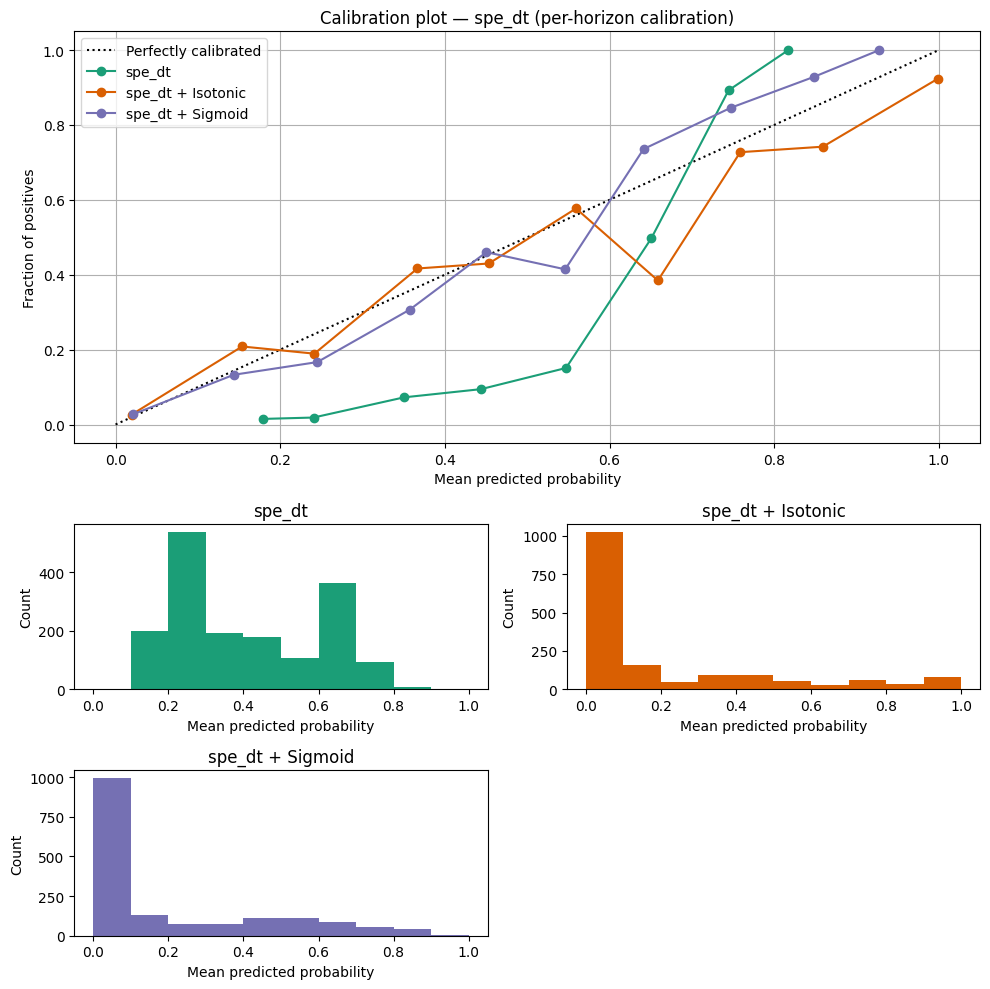

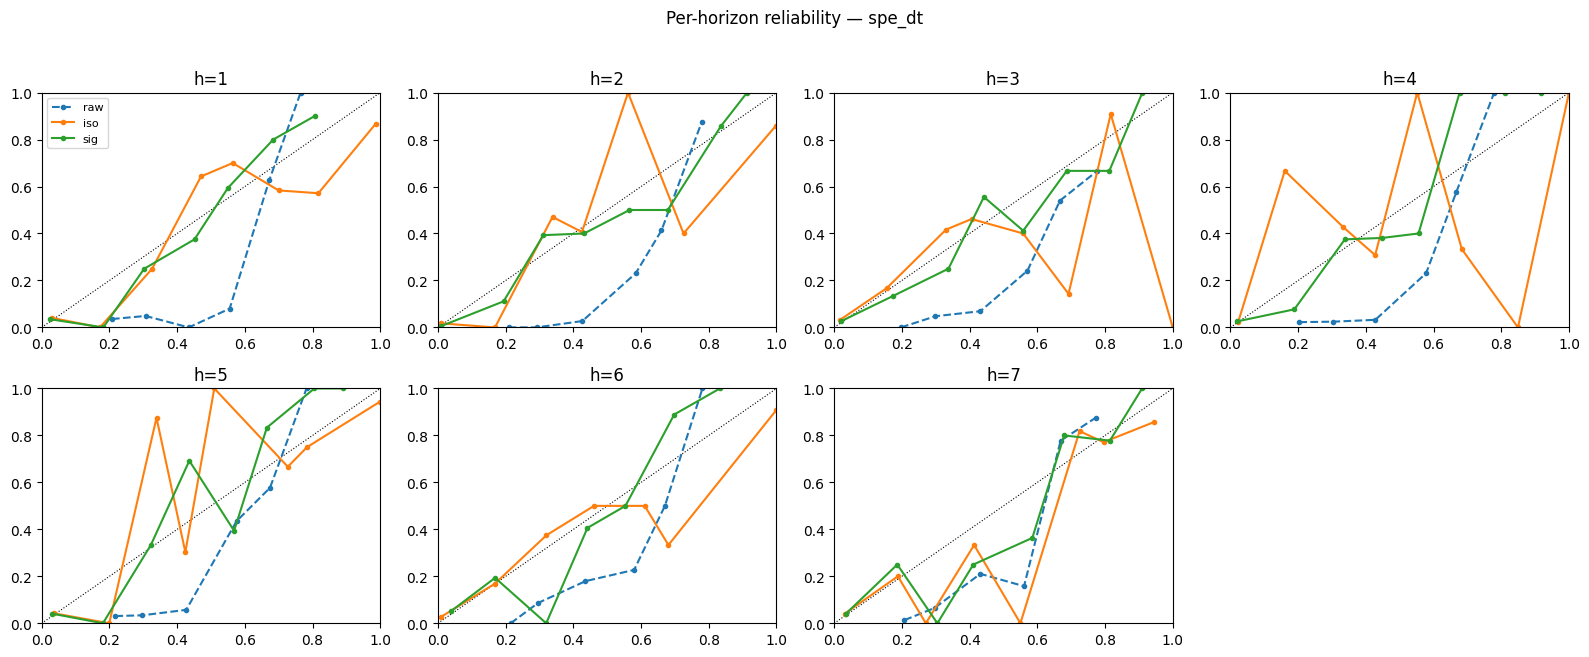

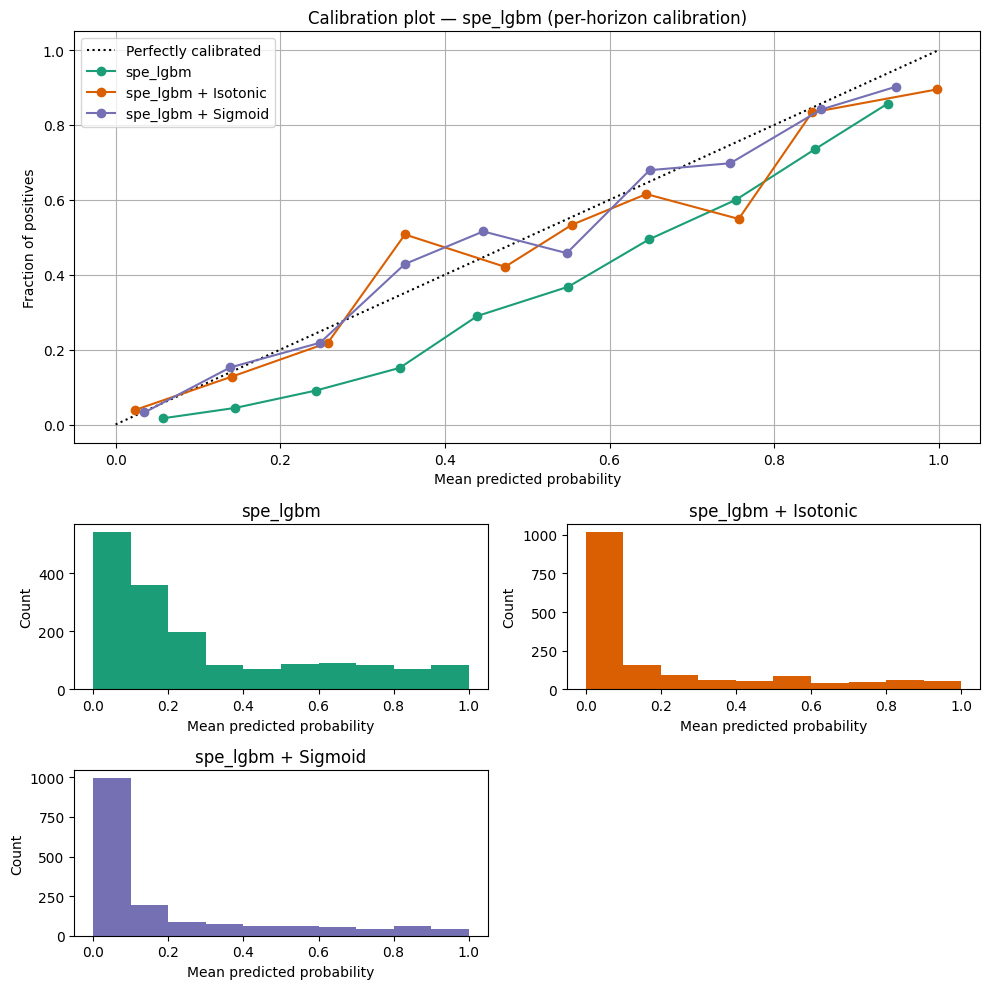

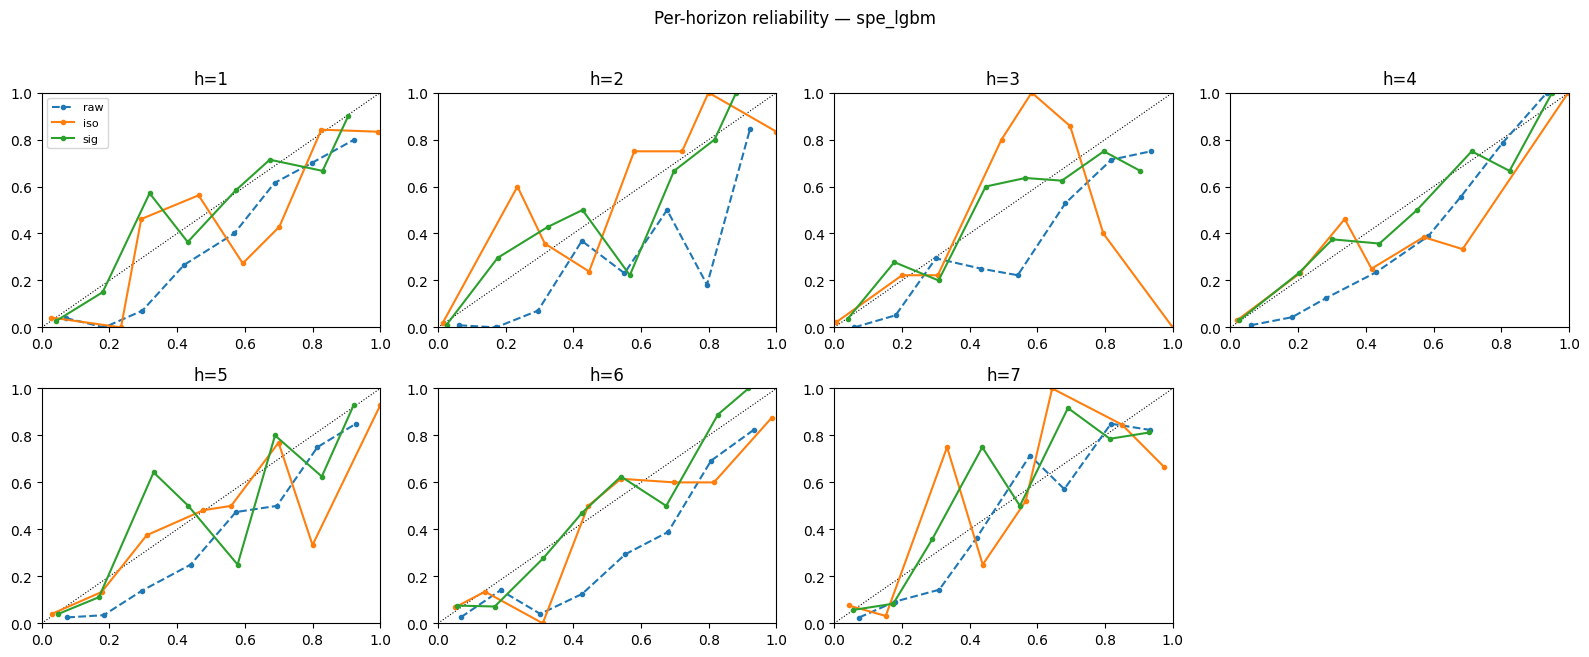

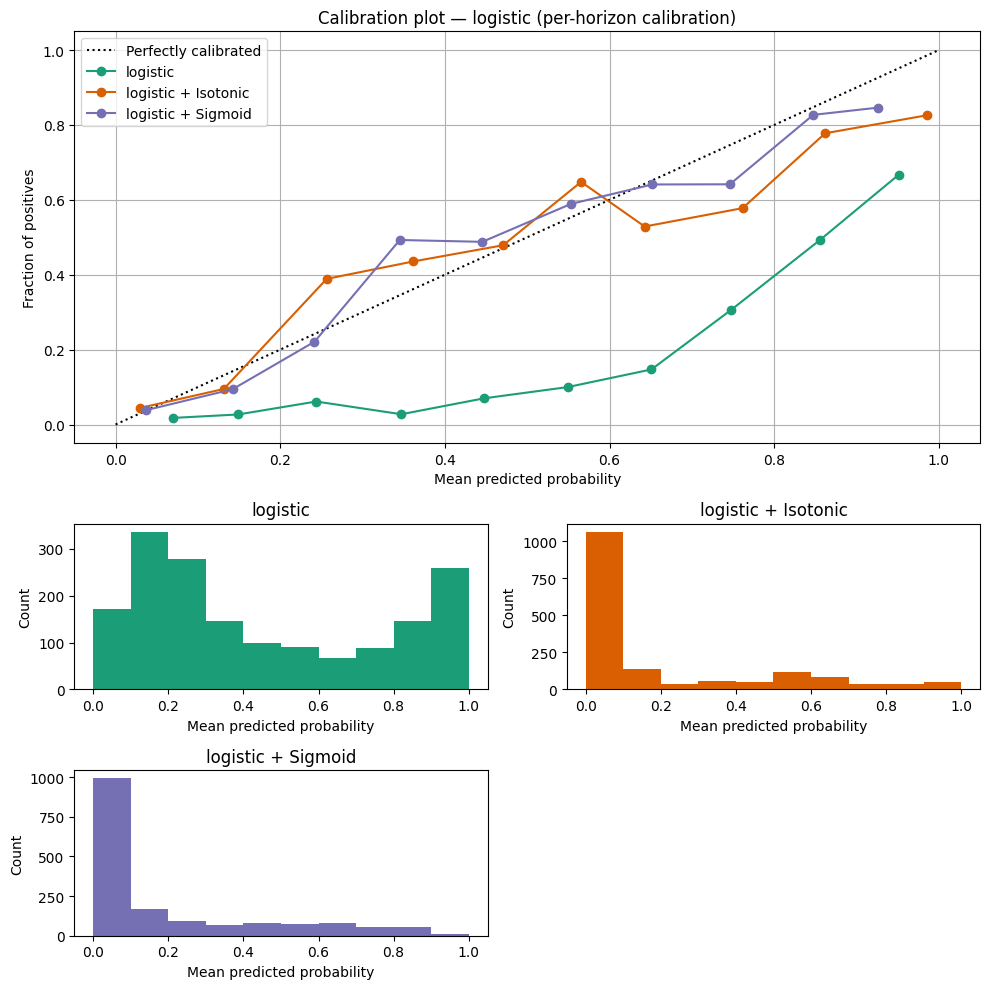

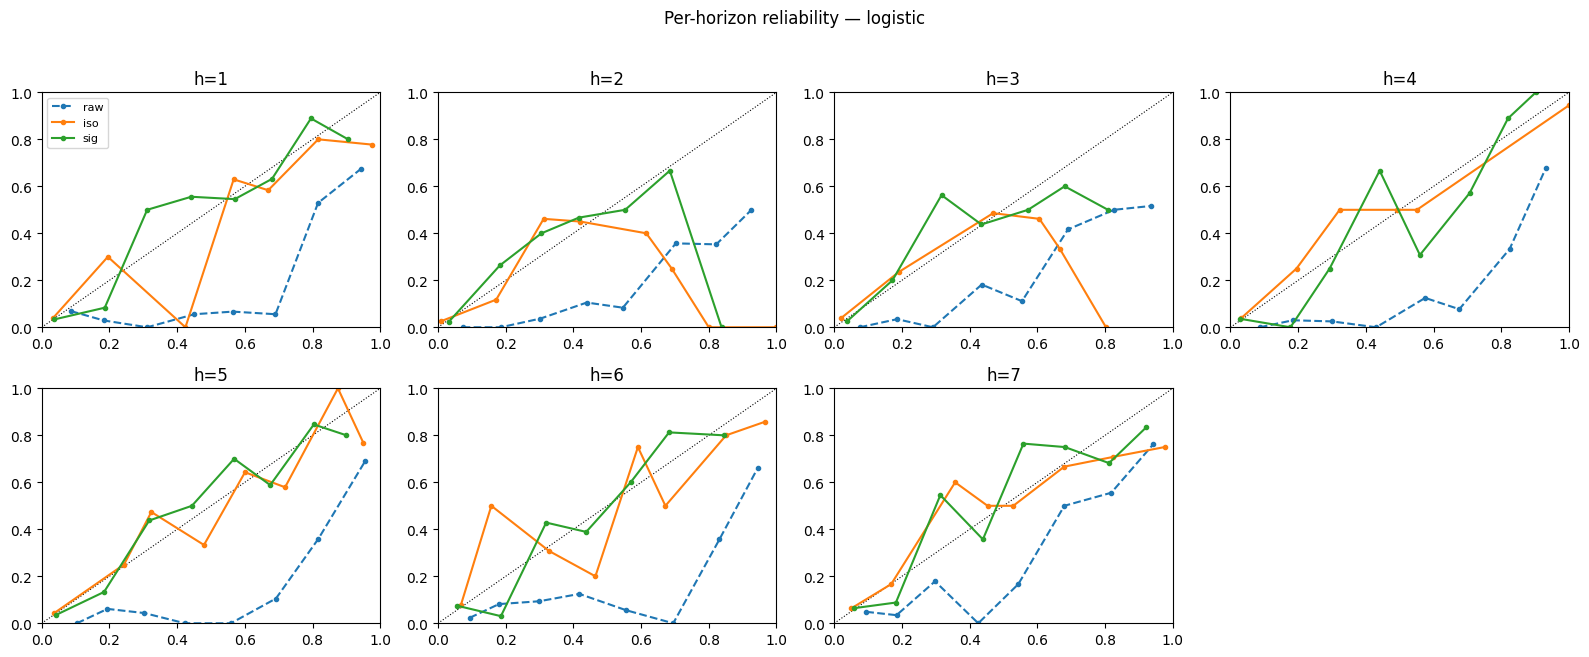

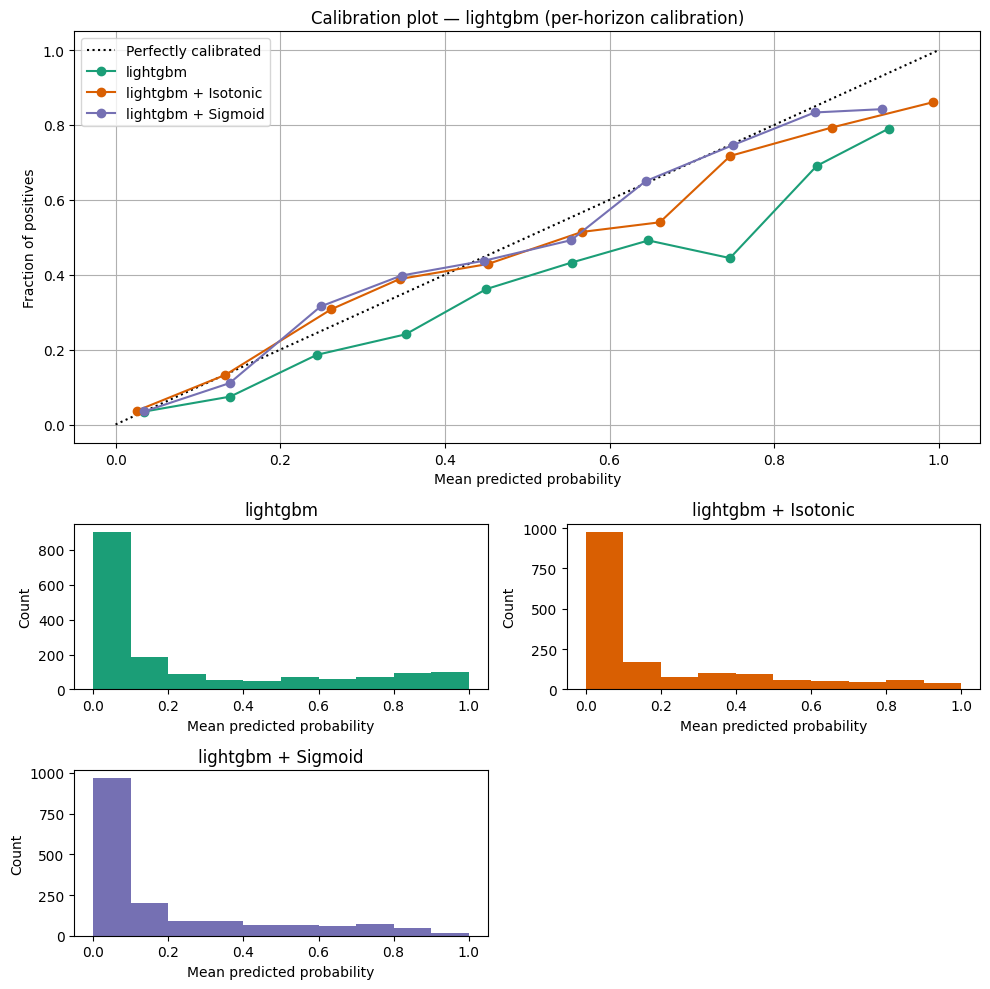

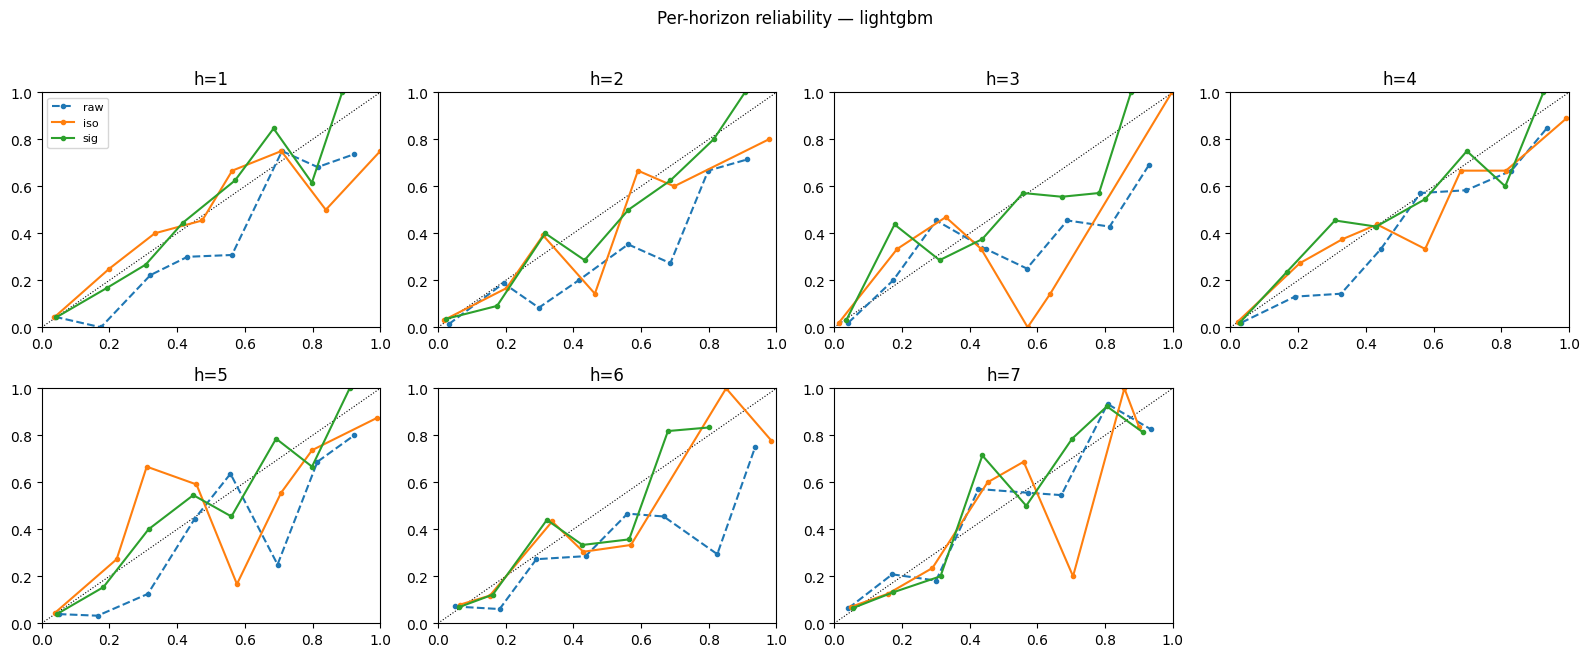

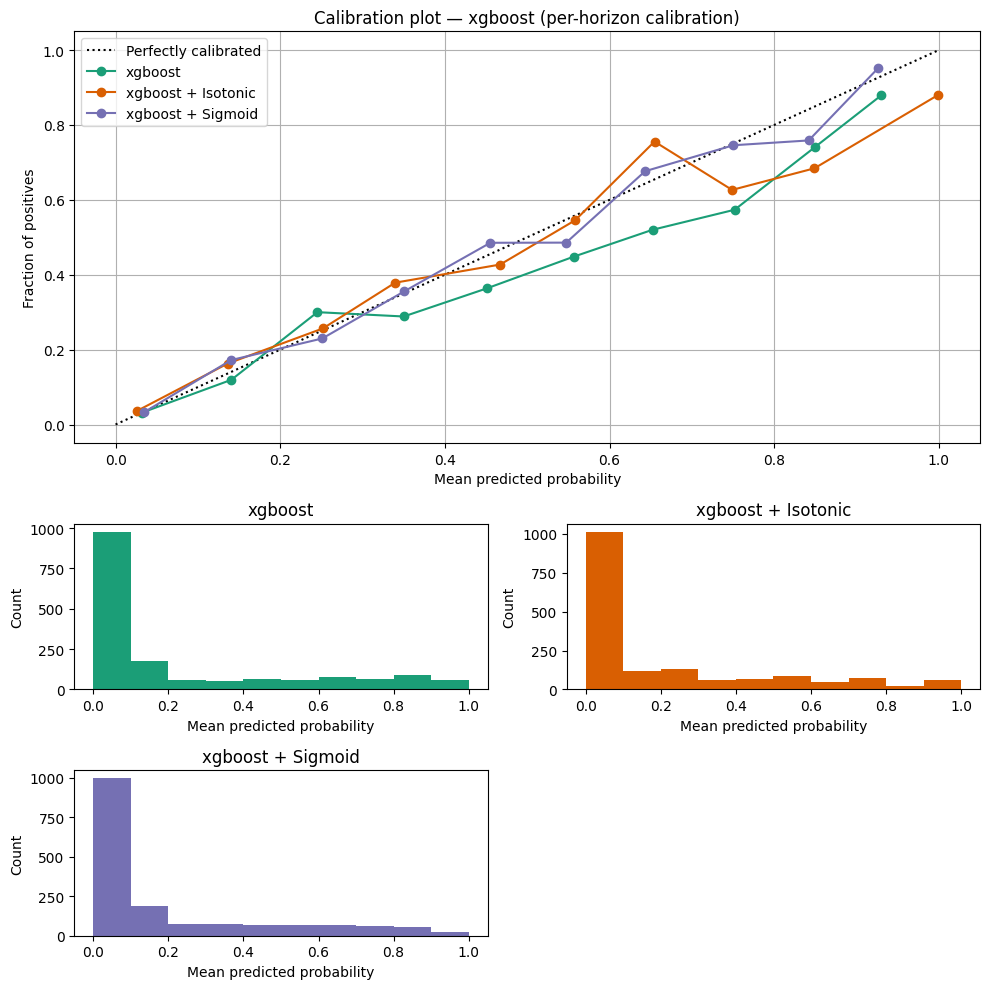

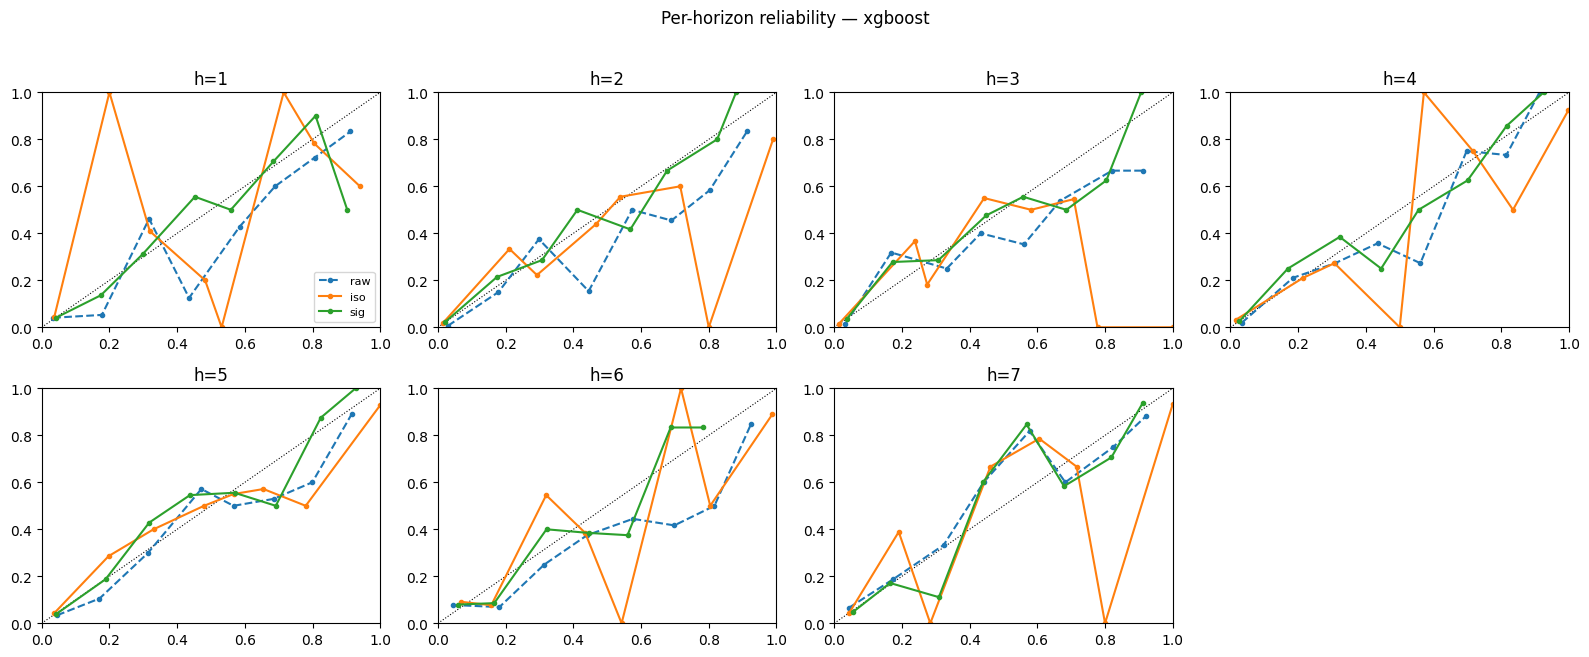

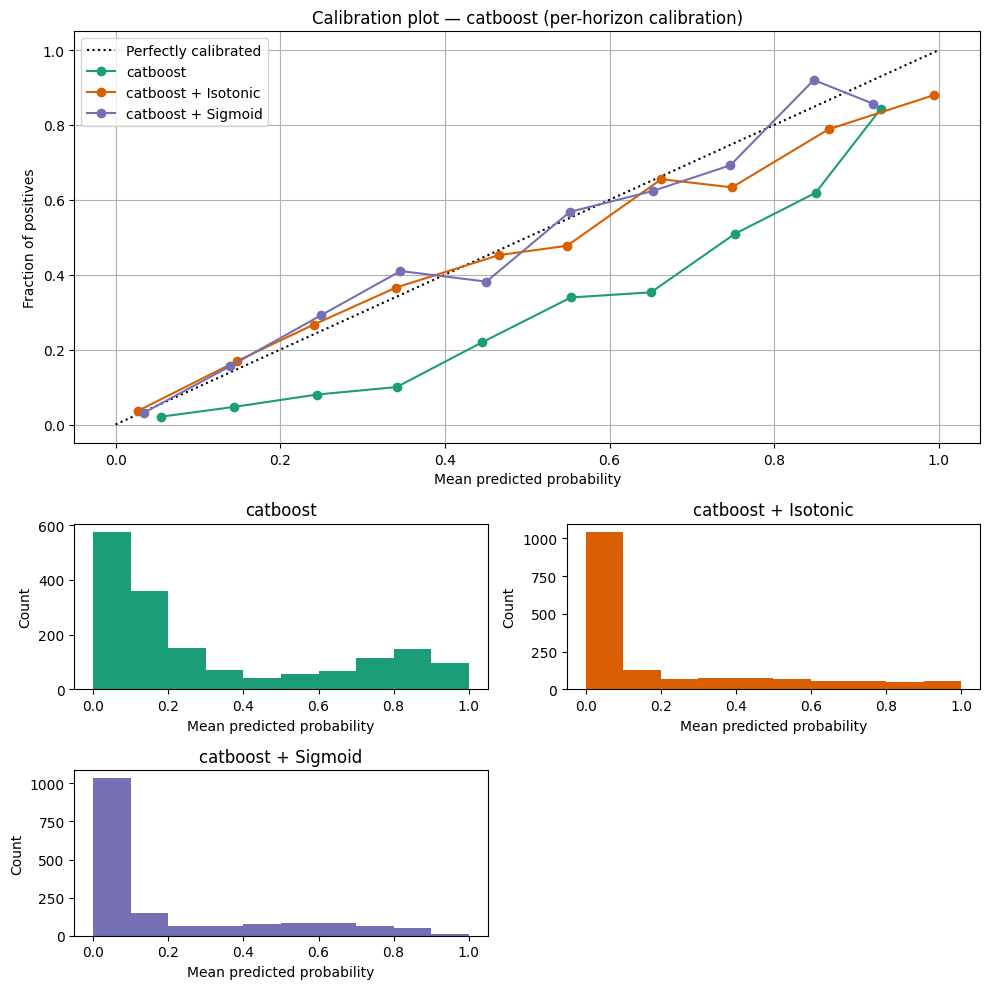

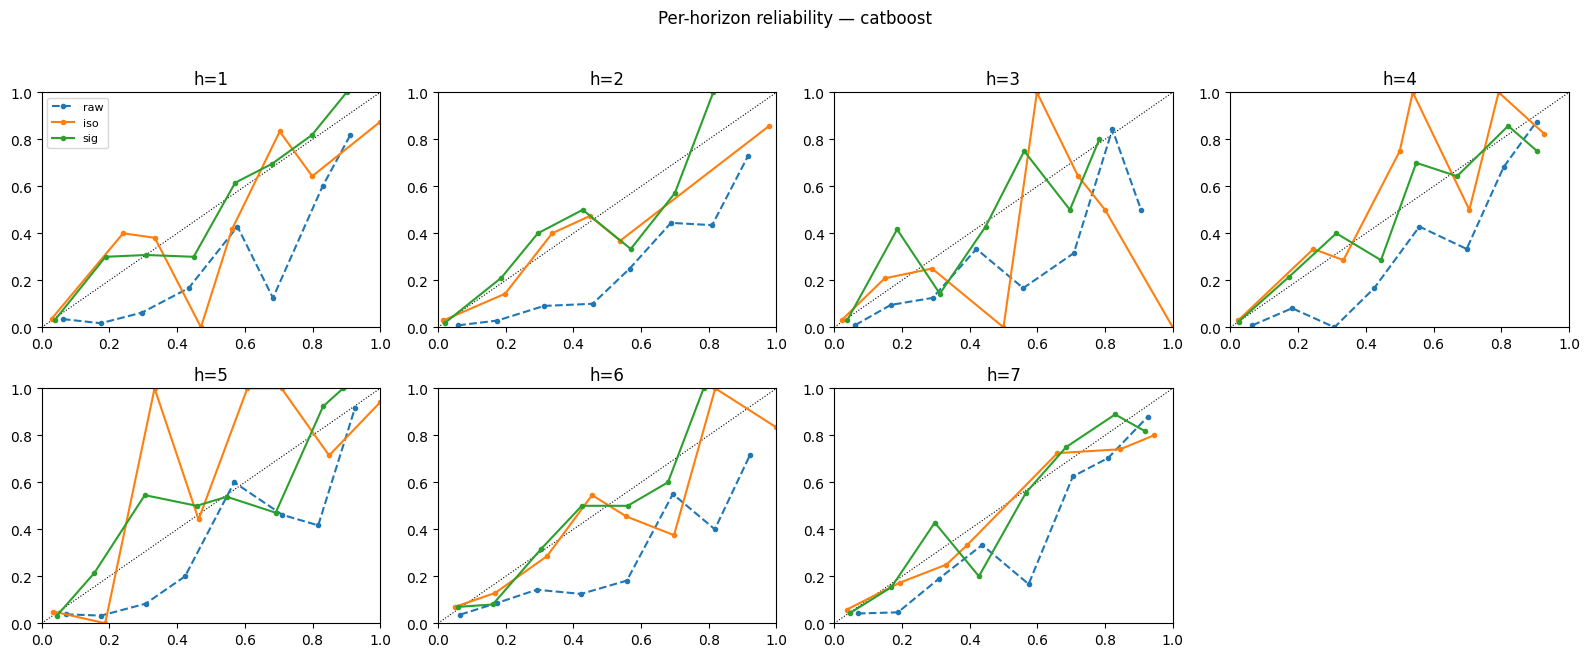

,Brier,LogLoss,ROC_AUC,PR_AUC
model,,,,
spe_dt + Sigmoid,0.0906,0.2993,0.9021,0.7345
spe_lgbm + Sigmoid,0.0914,0.3000,0.8990,0.7179
spe_dt + Isotonic,0.0916,0.3581,0.8992,0.7162
catboost + Sigmoid,0.0929,0.3049,0.8932,0.7034
xgboost + Sigmoid,0.0952,0.3088,0.8929,0.6966
spe_lgbm + Isotonic,0.0954,0.3831,0.8918,0.6908
lightgbm + Sigmoid,0.0969,0.3159,0.8867,0.6768
catboost + Isotonic,0.0970,0.3932,0.8824,0.6748
logistic + Sigmoid,0.0972,0.3183,0.8822,0.6667


horizon,1,2,3,4,5,6,7
model,,,,,,,
catboost,0.1171,0.1111,0.1142,0.0969,0.1174,0.1446,0.1085
catboost + Isotonic,0.0990,0.0808,0.0964,0.0797,0.0918,0.1225,0.1088
catboost + Sigmoid,0.0915,0.0766,0.0928,0.0789,0.0959,0.1144,0.0999
lightgbm,0.1065,0.0934,0.1137,0.0815,0.1029,0.1400,0.1076
lightgbm + Isotonic,0.1032,0.0832,0.1012,0.0836,0.1040,0.1208,0.1088
lightgbm + Sigmoid,0.0991,0.0782,0.0996,0.0801,0.0947,0.1187,0.1081
logistic,0.1835,0.1705,0.1652,0.1720,0.2176,0.1939,0.1567
logistic + Isotonic,0.0919,0.0968,0.1084,0.0748,0.1064,0.1064,0.1220
logistic + Sigmoid,0.0925,0.0881,0.1002,0.0763,0.0985,0.1052,0.1196


In [50]:
CALIBRATION_MODELS = [n for n in CLASSIFIERS_TO_RUN if n != "naive" and n in long_by_model]

calibration_rows_pooled    = []   # one row per (model, method)
calibration_rows_perhoriz  = []   # one row per (model, method, horizon)
calibrators_by_model       = {}   # name -> {"isotonic": {h: cal}, "sigmoid": {h: cal}}

for name in CALIBRATION_MODELS:
    long_df = long_by_model[name].reset_index(drop=True)   # clean 0..N-1 index for safe scatter

    # OOF calibrated probabilities WITHIN each horizon
    y_true, p_raw, p_iso = oof_calibrated_probs(long_df, method="isotonic", group_col="horizon")
    _,      _,     p_sig = oof_calibrated_probs(long_df, method="sigmoid",  group_col="horizon")

    # Main panel (pooled reliability, using per-horizon-calibrated probs)
    probs_by_method = {
        f"{name}":             p_raw,
        f"{name} + Isotonic":  p_iso,
        f"{name} + Sigmoid":   p_sig,
    }
    plot_calibration_panel(name, y_true, probs_by_method, n_bins=10)

    # Per-horizon reliability audit (shows whether each horizon individually got fixed)
    plot_per_horizon_reliability(name, long_df, p_raw, p_iso, p_sig, n_bins=8)

    # Pooled summary (same structure as before)
    for label, probs in probs_by_method.items():
        calibration_rows_pooled.append({
            "model": label,
            "Brier":   brier_score_loss(y_true, probs),
            "LogLoss": log_loss(y_true, np.clip(probs, _CAL_EPS, 1 - _CAL_EPS), labels=[0, 1]),
            "ROC_AUC": roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan,
            "PR_AUC":  average_precision_score(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan,
        })

    # Per-horizon breakdown — did calibration help uniformly, or just on average?
    h_arr = long_df["horizon"].to_numpy()
    for h in np.unique(h_arr):
        m = h_arr == h
        y_h = y_true[m]
        if len(np.unique(y_h)) < 2:   # can't compute ROC-AUC for a constant class
            roc_h = pr_h = np.nan
        for label, probs in probs_by_method.items():
            p_h = probs[m]
            calibration_rows_perhoriz.append({
                "model": label, "horizon": int(h),
                "Brier":   brier_score_loss(y_h, p_h),
                "LogLoss": log_loss(y_h, np.clip(p_h, _CAL_EPS, 1 - _CAL_EPS), labels=[0, 1]),
                "ROC_AUC": roc_auc_score(y_h, p_h) if len(np.unique(y_h)) > 1 else np.nan,
                "PR_AUC":  average_precision_score(y_h, p_h) if len(np.unique(y_h)) > 1 else np.nan,
                "n_pos":   int(y_h.sum()), "n": int(len(y_h)),
            })

    # FINAL calibrators (fit on all rows in each horizon) — these go to Stage 2
    calibrators_by_model[name] = {
        "isotonic": fit_final_calibrators_per_horizon(long_df, method="isotonic"),
        "sigmoid":  fit_final_calibrators_per_horizon(long_df, method="sigmoid"),
    }

calibration_df          = pd.DataFrame(calibration_rows_pooled).set_index("model").round(4).sort_values("Brier")
calibration_df_perhoriz = pd.DataFrame(calibration_rows_perhoriz).round(4)

print(calibration_df)
print(calibration_df_perhoriz.pivot_table(index=["model"], columns="horizon", values="Brier"))

## 11. Per-horizon comparison

Does the winner stay the winner at h=7? Sometimes a model has great h=1 but
degrades fastest. For the hurdle model the horizon that matters is the one
your downstream user acts on.


In [51]:
# Concatenate per-horizon tables with a model column for a side-by-side view
per_horizon_all = []
for name, res in results_by_model.items():
    t = res["per_horizon"].copy()
    t["model"] = name
    per_horizon_all.append(t)
per_horizon_all = pd.concat(per_horizon_all, ignore_index=True)

pivot_f1 = per_horizon_all.pivot(index="horizon", columns="model", values="F1")
pivot_auc = per_horizon_all.pivot(index="horizon", columns="model", values="PR_AUC")

print("F1 per horizon:")
print(pivot_f1.round(3))
print("\nPR-AUC per horizon:")
print(pivot_auc.round(3))
average_pr_auc = pivot_auc.mean()

print("Average PR-AUC over all horizons:")
print(average_pr_auc.round(3))




F1 per horizon:
model    catboost  lightgbm  logistic  naive  spe_dt  spe_lgbm  xgboost
horizon                                                                
1           0.699     0.673     0.730  0.618   0.746     0.714    0.680
2           0.598     0.578     0.558  0.532   0.620     0.558    0.627
3           0.596     0.558     0.598  0.594   0.629     0.598    0.615
4           0.710     0.718     0.717  0.552   0.679     0.722    0.659
5           0.715     0.720     0.698  0.566   0.701     0.718    0.707
6           0.600     0.581     0.661  0.550   0.614     0.619    0.604
7           0.754     0.740     0.707  0.656   0.758     0.760    0.738

PR-AUC per horizon:
model    catboost  lightgbm  logistic  naive  spe_dt  spe_lgbm  xgboost
horizon                                                                
1           0.740     0.686     0.732  0.449   0.788     0.733    0.678
2           0.636     0.635     0.494  0.344   0.655     0.644    0.636
3           0.599     0.611

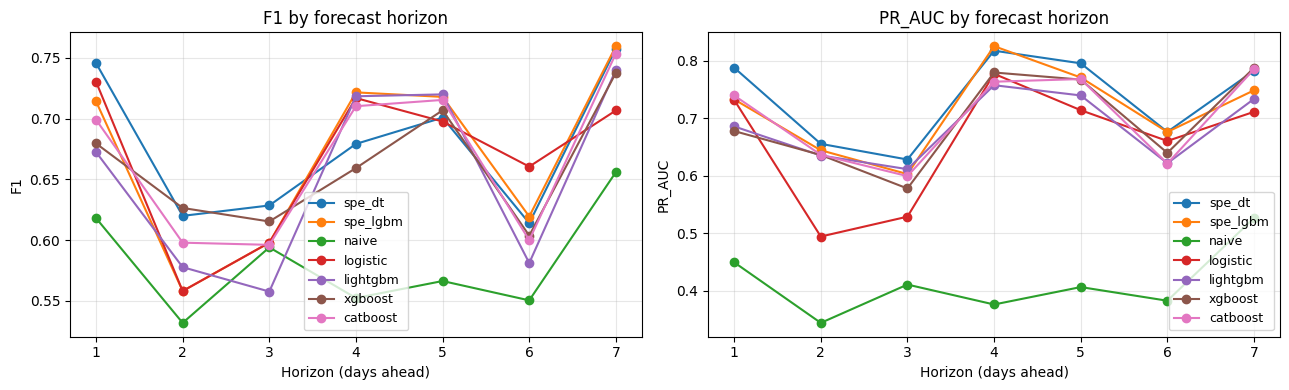

In [52]:
# Plot F1 and PR-AUC vs horizon
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for metric, ax in zip(["F1", "PR_AUC"], axes):
    for name in CLASSIFIERS_TO_RUN:
        if name not in results_by_model:
            continue
        t = results_by_model[name]["per_horizon"]
        ax.plot(t["horizon"], t[metric], marker="o", label=name)
    ax.set_xlabel("Horizon (days ahead)")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} by forecast horizon")
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 12. Per-region x horizon heatmap for the winning model

This shows *where* (region) and *when* (horizon day) the best classifier is
weak. High-variance regions (the fronts, Kyiv, Odesa) tend to be easier at
h=1 than peripheral regions; that dynamic is what the heatmap surfaces.


Winner (by PR-AUC): spe_dt


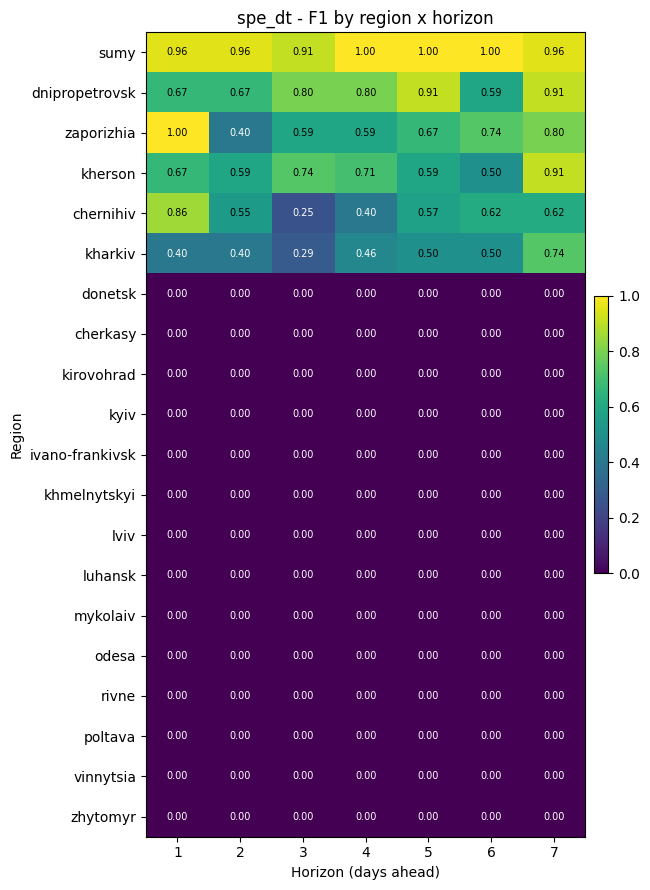

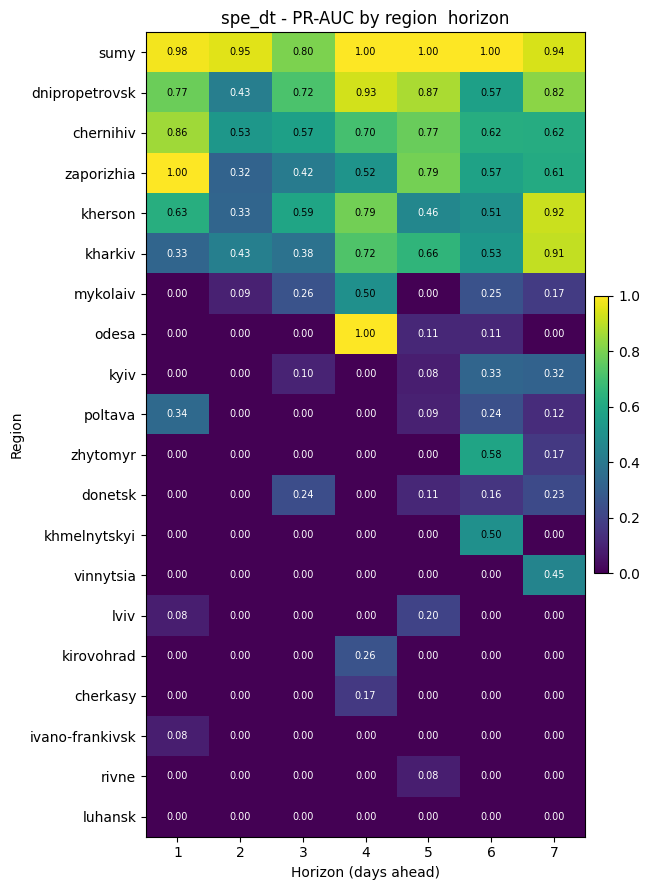

In [53]:
# Pick winner by PR-AUC (more appropriate than ROC-AUC under imbalance)
winner = leaderboard.iloc[0]["model"]
print(f"Winner (by PR-AUC): {winner}")

plot_region_horizon_heatmap(
    results_by_model[winner]["per_region_horizon"],
    metric="F1",
    title=f"{winner} - F1 by region x horizon",
    vmin=0, vmax=1,
)
plt.show()

plot_region_horizon_heatmap(
    results_by_model[winner]["per_region_horizon"],
    metric="PR_AUC",
    title=f"{winner} - PR-AUC by region  horizon",
    vmin=0, vmax=1,
)
plt.show()


## 13. Per-region detail for the winning model

In [54]:
results_by_model[winner]["per_region"]


,F1,Precision,Recall,ROC_AUC,PR_AUC,Brier,TP,FP,TN,FN,n,region
0,0.969325,0.940476,1.000000,0.521519,0.955061,0.090834,79,5,0,0,84,sumy
1,0.773723,0.630952,1.000000,0.538040,0.698698,0.233507,53,31,0,0,84,dnipropetrovsk
2,0.707692,0.547619,1.000000,0.574943,0.663747,0.255356,46,38,0,0,84,zaporizhia
3,0.682540,0.518072,1.000000,0.509926,0.599783,0.268553,43,40,1,0,84,kherson
4,0.578313,0.521739,0.648649,0.661300,0.591578,0.262937,24,22,25,13,84,chernihiv
5,0.480769,0.324675,0.925926,0.654321,0.460458,0.311610,25,52,5,2,84,kharkiv
6,0.000000,0.000000,0.000000,0.287570,0.063410,0.241349,0,0,77,7,84,donetsk
7,0.000000,0.000000,0.000000,0.409639,0.020000,0.061638,0,0,83,1,84,cherkasy
8,0.000000,0.000000,0.000000,0.432927,0.040598,0.095595,0,0,82,2,84,kirovohrad
9,0.000000,0.000000,0.000000,0.506579,0.108193,0.175678,0,0,76,8,84,kyiv


## 14. Feature importance for the winning model (tree models only)

For multi-output direct classifiers, each horizon has its own sub-estimator,
so we emit importance per horizon day. The first column (`h=1`) is usually
the most trustworthy - longer horizons spread importance over more lagged
features.


In [55]:
# feature_importances_per_horizon imported from src


## 15. Handing off to Stage 2 (the regressor)

For the hurdle model you need, from this notebook:

1. **The chosen classifier** (winner above), with its **tuned threshold**.
2. **The predicted probability** at each (region, date, horizon) - the long
   DataFrame `long_by_model[winner]` already is that, for your CV window.
3. **The positive-only rows** that stage 2 will train on. The next notebook
   should filter `act_drone_strike_on_ua > 0` from `master_timeseries` and
   model the *count* on that subset.

Two coupling choices to make in Stage 2:

- **Hard gate**: multiply the stage-2 count prediction by `1[p >= threshold]`.
  Simple, but any stage-1 false negative is a permanent zero.
- **Soft gate**: emit `E[count] ≈ p * E[count | count>0]`. Respects calibration,
  which is why we reported Brier above. This is why picking a *calibrated*
  classifier matters, and why Logistic Regression is worth keeping in the
  comparison even if its F1 loses.

Save the inputs Stage 2 needs:


In [56]:
# Persist the winner's predictions and the threshold
winner_long = long_by_model[winner].copy()
winner_long["threshold"] = results_by_model[winner]["threshold"]
winner_long.to_parquet(f"./stage1_predictions_{winner}.parquet", index=False)
leaderboard.to_csv("./stage1_leaderboard.csv", index=False)
print(f"Saved stage1_predictions_{winner}.parquet and stage1_leaderboard.csv")


Saved stage1_predictions_spe_dt.parquet and stage1_leaderboard.csv


## 16. (Optional) Optuna tuning of the winning classifier

Now that we've identified a leader, we can tune it. Unlike the original
notebook, this objective uses a **classification** metric (PR-AUC) on the
tuning fold, and the search space is scoped to the winning estimator only.

> Run this only after the leaderboard has stabilised - tuning before
> comparing is a common pitfall (you risk tuning a weak model into appearing
> strong and never trying the fundamentally better one).


In [57]:
import optuna

TUNE_FRACTION = 0.80
tune_series   = [ts.split_after(TUNE_FRACTION)[0] for ts in target_series_list]
TUNE_CV_START = 0.70 / TUNE_FRACTION  # = 0.875
TUNE_HORIZON  = OUTPUT_CHUNK_LEN
TUNE_STRIDE   = 14
N_TRIALS      = 30


def _tune_objective_lightgbm(trial):
    from darts.models import LightGBMClassifierModel
    params = {
        "num_leaves":        trial.suggest_int("num_leaves", 15, 127),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "n_estimators":      trial.suggest_int("n_estimators", 100, 1000, step=100),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "feature_fraction":  trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction":  trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq":      trial.suggest_int("bagging_freq", 0, 7),
    }
    model = LightGBMClassifierModel(
        **COMMON_KWARGS,
        objective="binary", is_unbalance=True,
        random_state=RANDOM_STATE, verbose=-1,
        **params,
    )
    try:
        fold_preds = model.historical_forecasts(
            series=tune_series, past_covariates=full_past_covs, future_covariates=full_fut_covs,
            start=TUNE_CV_START, forecast_horizon=TUNE_HORIZON, stride=TUNE_STRIDE,
            retrain=True, last_points_only=False, verbose=False, show_warnings=False,
        )
    except Exception as e:
        print(f"trial {trial.number}: {type(e).__name__}: {e}")
        return 0.0

    long_df = collect_predictions_long(tune_series, fold_preds, region_names)
    # Maximise PR-AUC (threshold-free, imbalance-aware)
    m = _classif_metrics(long_df["y_true"], long_df["y_prob"], threshold=0.5)
    return m["PR_AUC"] if not np.isnan(m["PR_AUC"]) else 0.0


# Only runs if the winner is LightGBM; add analogous `_tune_objective_xgboost`, etc., if needed
if winner == "lightgbm":
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(_tune_objective_lightgbm, n_trials=N_TRIALS, show_progress_bar=True)
    print("Best PR-AUC:", study.best_value)
    print("Best params:", study.best_params)
else:
    print(f"Winner is {winner}; implement _tune_objective_{winner} analogously.")


Winner is spe_dt; implement _tune_objective_spe_dt analogously.
